In [1]:
#import all packages
import numpy as np
import oiffile
import matplotlib.pyplot as plt
from functools import partial
from pycpd import RigidRegistration
from pycpd import AffineRegistration
from pycpd import DeformableRegistration
from PIL import Image
from skimage import io

In [2]:
#define all functions
def get_proj(stack,channel):
    two_p_stack=oiffile.imread(stack)
    n_frames=two_p_stack.shape[1]
    two_p_stack=two_p_stack[channel,29:32,:,:]
    mean_proj=np.mean(two_p_stack,axis=0)
    plt.figure(figsize=(6,6))
    plt.title('Mean projection')
    plt.imshow(mean_proj)
    np.save('mean_proj.npy',mean_proj)
    return n_frames
    
def plot_point_overlay(image,points,siz):
    fig,ax=plt.subplots(figsize=(siz[0],siz[1]))
    ax.imshow(image,cmap='gray')
    ax.scatter(points[:,0],points[:,1],c='red',s=5,marker=None)
    return fig,ax

def point_set(pict,filename,coordinates,):
    if isinstance(pict,np.ndarray):
        points=np.array(coordinates)
        size=[8,6]
        plot_point_overlay(pict,points,size)
        np.savetxt(filename,points)
    else:
        pict=np.load(pict,allow_pickle=True)
        points=np.array(coordinates)
        size=[6,6]
        plot_point_overlay(pict,points,size)
        np.savetxt(filename,points)
        
def visualize(iteration, error, X, Y, ax):
    plt.cla()
    ax.invert_yaxis()
    ax.scatter(X[:, 0],  X[:, 1], color='red', label='Target')
    ax.scatter(Y[:, 0],  Y[:, 1], color='blue', label='Source')
    ax.legend(loc='upper left', fontsize='small')
    ax.set_title('After transformation')

def main(target,source):
    X = np.loadtxt(target)
    Y = np.loadtxt(source)
    
    fig= plt.figure()
    ax=fig.add_axes([0, 0, 1, 1])
    ax.invert_yaxis()
    ax.scatter(X[:, 0],  X[:, 1], color='red', label='Target')
    ax.scatter(Y[:, 0],  Y[:, 1], color='blue', label='Source')
    ax.set_title('Before transformation')
    
    fig.add_axes([1.2, 0, 1, 1])
    callback = partial(visualize,ax=fig.axes[1])
    reg = RigidRegistration(**{'X': X, 'Y': Y})
    reg.register(callback)
    TY,(s_reg,B_reg,t_reg)=reg.register()

    fig.set_figwidth(5)
    fig.set_figheight(4)
    
    return TY,s_reg,B_reg,t_reg,X,Y

def main0(target,source):
    X = np.loadtxt(target)
    Y = np.loadtxt(source)
    fig = plt.figure()
    fig.add_axes([0, 0, 1, 1])
    callback = partial(visualize,ax=fig.axes[0])
    reg = RigidRegistration(**{'X': X, 'Y': Y})
    reg.register(callback)
    TY,(s_reg,B_reg,t_reg)=reg.register()
    plt.show()
    return TY,s_reg,B_reg,t_reg,X,Y

def before_reg():
    X = np.loadtxt(target)
    Y = np.loadtxt(source)
    fig = plt.figure(figsize=[5,4])
    fig.add_axes([0, 0, 1, 1])
    ax=fig.axes[0]
    ax.invert_yaxis()
    ax.scatter(X[:, 0],  X[:, 1], color='red', label='Target')
    ax.scatter(Y[:, 0],  Y[:, 1], color='blue', label='Source')
    ax.legend(loc='upper left', fontsize='large')

def apply_transform(onep_image,s,r,t):
    row,col=onep_image.shape
    one_T=np.zeros([1500,1500])
    for y in range(row):
        for x in range(col):
            [Tx,Ty]=np.matmul([x*s,y*s],r)+t
            Tx=np.around(Tx).astype(int)
            Ty=np.around(Ty).astype(int)
            one_T[Ty,Tx]=one_p[y,x]
    plt.figure(figsize=[6,6])
    plt.imshow(one_T)
    return one_T

def transform_repair(onep_transformed):
    cropped_one_T1=np.zeros((642,642))
    cropped_one_T1[1:-1,1:-1]=onep_transformed
    cropped_one_T2=cropped_one_T1
    for y1 in range(1,641):
        for x1 in range(1,641):
            if cropped_one_T2[y1,x1]==0:
                cropped_one_T2[y1,x1]=np.mean((cropped_one_T1[y1-1,x1],cropped_one_T1[y1+1,x1],cropped_one_T1[y1,x1-1],cropped_one_T1[y1,x1+1]))
    cropped_one_T3=cropped_one_T2[1:641,1:641]
    plt.imshow(cropped_one_T3)
    return cropped_one_T3

def check_image_sizes(img0,img1):
    if img0.size==img1.size:
        print('images size-matched')
    else:
        print('images are of different sizes')

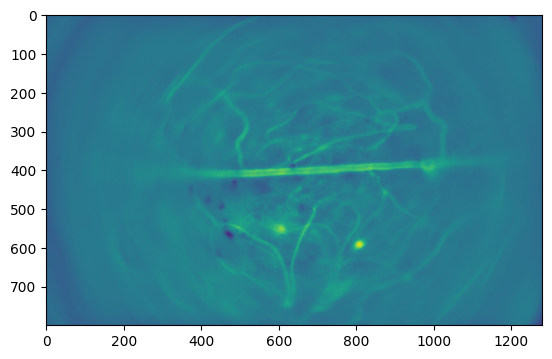

In [3]:
#load 1P image
one_p=plt.imread('./1P_MAXproj.tiff')
plt.imshow(one_p)
plt.imsave('one_p.png',one_p)

33

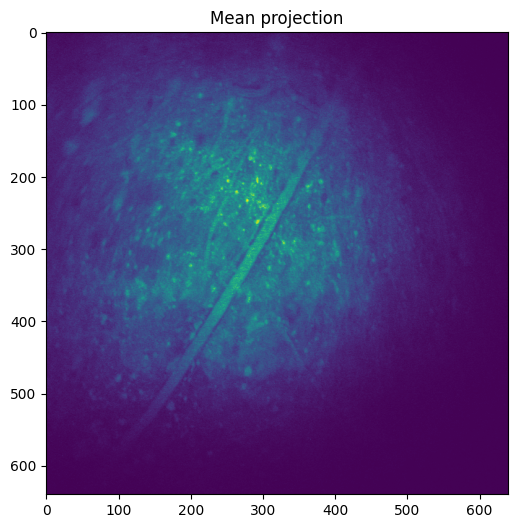

In [4]:
#get projections of the vessels of the 2P image stack
get_proj('./vessel&plaque2.oif',1)

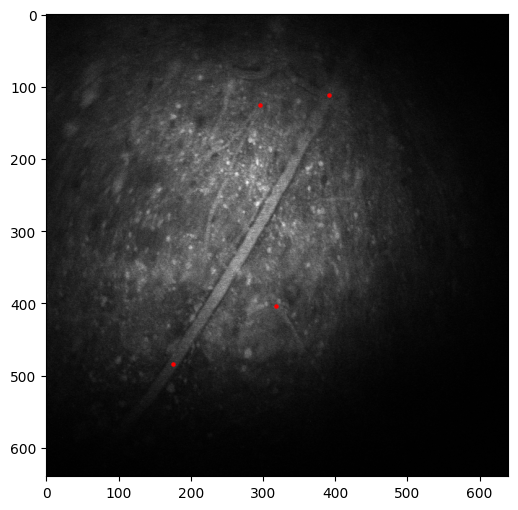

In [5]:
#find landmark points on 2P vessels
point_set('mean_proj.npy','points_target.txt',[[391,111],[175,484],[296,125],[318,403]])

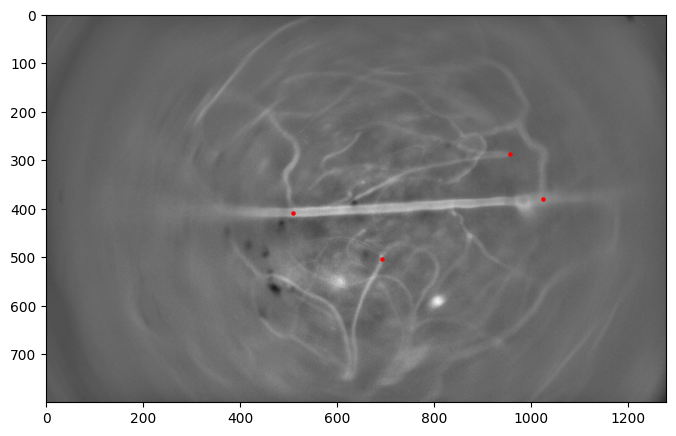

In [6]:
#find landmark points on 1P vessels
point_set(one_p,'points_source.txt',[[1025,380],[510,408],[957,287],[692,503]])

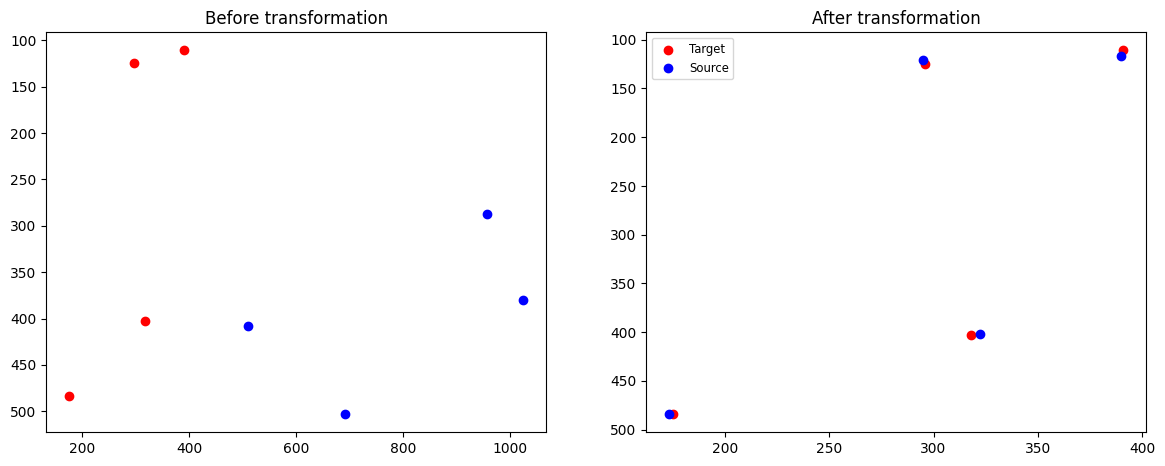

In [7]:
#calculate transformation parameters
target='./points_target.txt'
source='./points_source.txt'
TY,s_reg,B_reg,t_reg,X,Y=main(target,source)

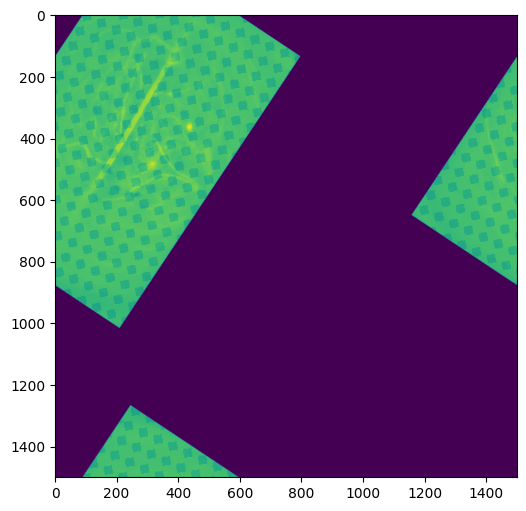

In [9]:
#apply the transformation parameters to 1P vessel image and save
one_T=apply_transform(one_p,s_reg,B_reg,t_reg)
plt.imsave('one_p_transformed.png',one_T)

np.float64(1832.0)

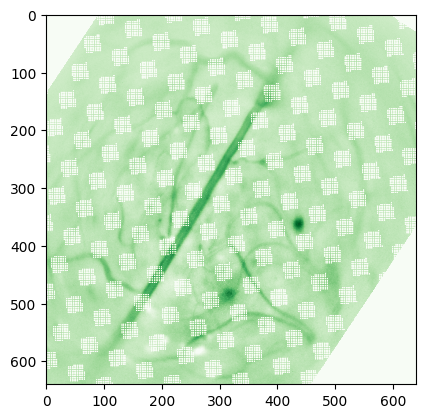

In [10]:
#crop transformed 1P vessel image for alignment with 2P image
cropped_one_T=one_T[:640,:640]
plt.imsave('cropped_one_p_transformed.png',cropped_one_T)
plt.imshow(cropped_one_T,cmap='Greens',vmin=1100,vmax=1832)
plt.imsave('cropped_one_p_transformed_cmap.png',cropped_one_T,cmap='Greens',vmin=1100,vmax=1832)
np.max(cropped_one_T)

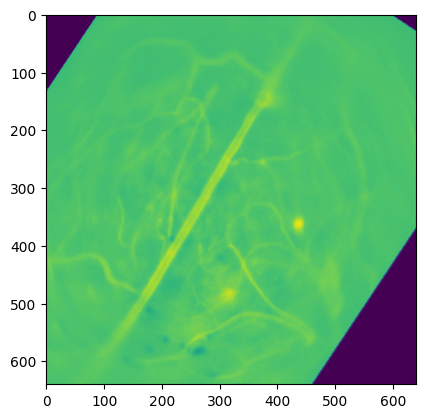

In [11]:
#repair lost pixels during transformation with interpolation
cropped_one_T3=transform_repair(cropped_one_T)

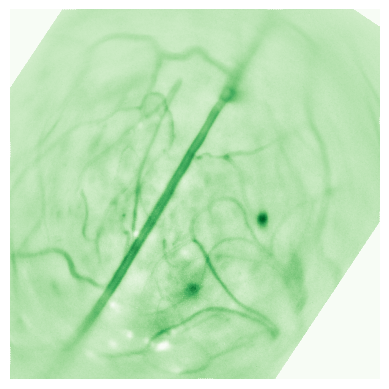

In [12]:
#save the final transformed 1P vessel image
plt.figure()
plt.imshow(cropped_one_T3,cmap='Greens',vmin=1100,vmax=1832)
plt.axis('off')
plt.imsave('cropped_one_p_transformed_cmap_corrected.tiff',cropped_one_T3,cmap='Greens',vmin=1100,vmax=1832)
plt.imsave('cropped_one_p_transformed_cmap_red_corrected.tiff',cropped_one_T3,cmap='Reds',vmin=1100,vmax=1832)
plt.imsave('cropped_one_p_transformed_cmap_blue_corrected.tiff',cropped_one_T3,cmap='Greys',vmin=1100,vmax=1832)

np.float64(3594.6666666666665)

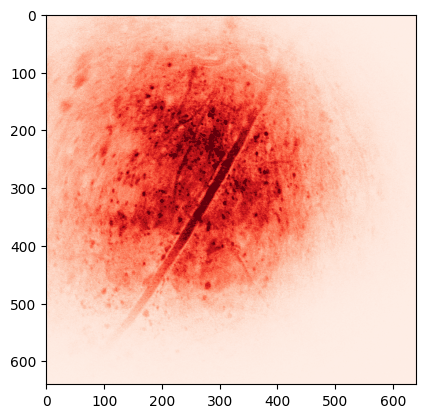

In [13]:
#load and display 2P vessel image
O_0=np.load('mean_proj.npy')
plt.imshow(O_0,cmap='Reds',vmin=0,vmax=2000)
plt.imsave('two_p_cmap.png',O_0,cmap='Reds',vmin=0,vmax=2000)
np.max(O_0)

In [14]:
#load transformed 1P and 2P vessel images
transformed_one_p = Image.open('cropped_one_p_transformed_cmap_corrected.tiff')
two_p = Image.open('two_p_cmap.png')

In [15]:
#cross-check image sizes
check_image_sizes(transformed_one_p,two_p)

images size-matched


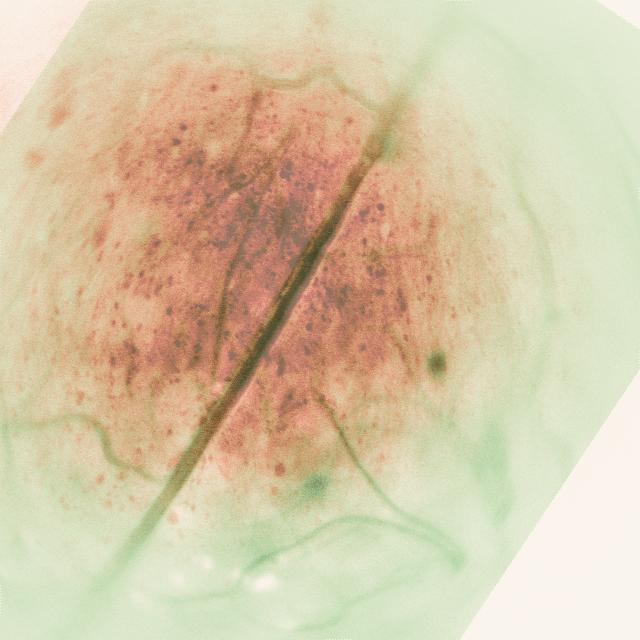

In [16]:
#superimpose transformed 1P vessel image onto 2P image
overlaid=Image.blend(two_p,transformed_one_p,0.5)
overlaid.save('1P_2P_merged_vessels.png')
overlaid